# Dimensionnement : CPU vs mémoire

Jusqu'ici, on a toujours regardé le CPU (notebook 03) et la mémoire (notebook 06)
séparément, et toujours face au coût. On ne les a jamais comparés entre eux. Une
ressource qui pousse le CPU à fond sans presque toucher à sa mémoire (ou l'inverse)
est peut-être sur le mauvais type de machine, donc mal dimensionnée pour ce qu'elle
fait. C'est ce qu'on regarde ici, en comparant `cpu_util_pct` et
`memory_util_pct`.

## 1. Chargement

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/gcp_costs_clean.csv", parse_dates=["usage_start", "usage_end"])
df[["resource_id", "service", "cpu_util_pct", "memory_util_pct", "cost_usd"]].head()

,resource_id,service,cpu_util_pct,memory_util_pct,cost_usd
0,res-ST6BAJ2N,Cloud Dataproc,92.72,70.42,5004.12
1,res-TYGNR0RV,Pub/Sub,37.78,46.80,4710.01
2,res-S3I9C869,BigQuery,82.54,59.47,843.22
3,res-1RY9BZ6G,Cloud Endpoints,86.68,97.63,1822.18
4,res-S3HQYIZ2,Cloud Spanner,82.95,21.58,2046.17


## 2. CPU et mémoire vont-ils ensemble ?

Une ressource qui utilise beaucoup de CPU utilise-t-elle aussi beaucoup de mémoire ?

In [2]:
df["cpu_util_pct"].corr(df["memory_util_pct"])

np.float64(0.01376495089163012)

<Axes: title={'center': 'Utilisation mémoire vs utilisation CPU'}, xlabel='cpu_util_pct', ylabel='memory_util_pct'>

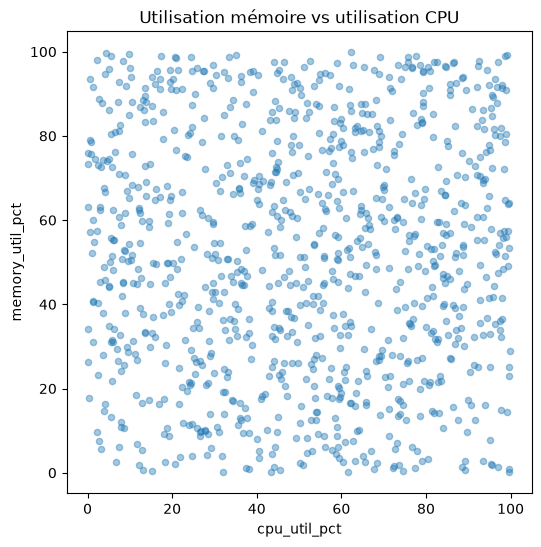

In [3]:
df.plot(
    kind="scatter", x="cpu_util_pct", y="memory_util_pct", alpha=0.4, figsize=(6, 6),
    title="Utilisation mémoire vs utilisation CPU",
)

Corrélation nulle et le nuage de points est sans forme donc le CPU et la mémoire d'une ressource n'ont rien à voir l'un avec l'autre.

## 3. L'écart CPU - mémoire

On calcule la différence entre les deux. Proche de 0, la ressource utilise autant de
CPU que de mémoire. Loin de 0 (positif ou négatif), elle penche fort d'un côté.

In [4]:
df["ecart_cpu_mem"] = df["cpu_util_pct"] - df["memory_util_pct"]

df["ecart_cpu_mem"].describe().round(1)

count    1000.0
mean       -0.7
std        40.2
min       -95.8
25%       -28.4
50%         0.2
75%        28.7
max        99.5
Name: ecart_cpu_mem, dtype: float64

## 4. Profils de ressources

Avec `pd.cut`, on découpe l'écart en trois profils : `memoire-dominant` (écart négatif), `equilibre` (proche de 0) et `cpu-dominant` (écart positif).

In [5]:
df["profil"] = pd.cut(
    df["ecart_cpu_mem"],
    bins=[-100, -20, 20, 100],
    labels=["memoire-dominant", "equilibre", "cpu-dominant"],
)

df["profil"].value_counts()

profil
equilibre           369
memoire-dominant    317
cpu-dominant        314
Name: count, dtype: int64

<Axes: title={'center': 'Nombre de ressources par profil'}, xlabel='profil'>

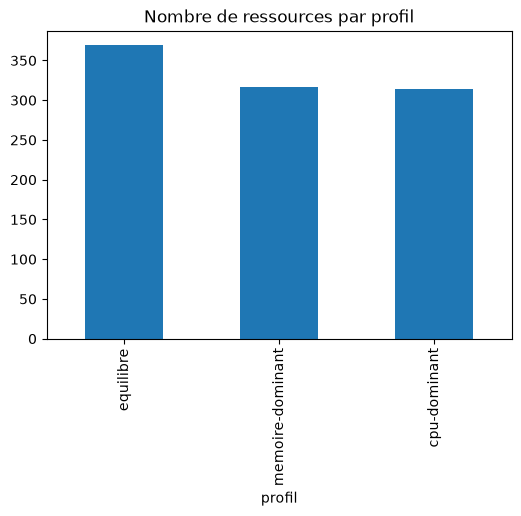

In [6]:
df["profil"].value_counts().plot(
    kind="bar", figsize=(6, 4), title="Nombre de ressources par profil"
)

## 5. Profil et coût

In [7]:
df.groupby("profil", observed=True).agg(
    nb_ressources=("resource_id", "count"),
    cout_total=("cost_usd", "sum"),
    cout_moyen=("cost_usd", "mean"),
).round(1)

,nb_ressources,cout_total,cout_moyen
profil,,,
memoire-dominant,317,679954.6,2145.0
equilibre,369,793711.3,2151.0
cpu-dominant,314,661549.2,2106.8


Les trois profils pèsent à peu près le même nombre de ressources et surtout le même coût moyen donc avoir un déséquilibre entre CPU/mémoire ne coûte ni plus ni moins cher.

## 6. Les cas les plus extrêmes

Les ressources où l'écart est le plus grand, dans un sens ou dans l'autre.

In [8]:
df.reindex(df["ecart_cpu_mem"].abs().sort_values(ascending=False).index)[
    ["resource_id", "service", "region", "cpu_util_pct", "memory_util_pct", "ecart_cpu_mem", "cost_usd"]
].head(10).round(1)

,resource_id,service,region,cpu_util_pct,memory_util_pct,ecart_cpu_mem,cost_usd
175,res-GL3BFL4Z,Cloud Interconnect,asia-southeast1,99.6,0.1,99.5,46.3
46,res-UB3MG63E,Cloud NAT,us-west1,99.7,0.9,98.8,719.8
131,res-IVCT1BUF,Cloud Data Fusion,southamerica-east1,2.2,98.0,-95.8,4606.7
92,res-W17TJLS5,Cloud SQL,northamerica-northeast1,97.0,1.5,95.6,3018.4
287,res-88VX0F0Q,Pub/Sub,asia-northeast1,4.5,99.8,-95.3,2180.4
838,res-T0HRH0Q7,Cloud Build,us-east1,95.5,1.8,93.7,4344.3
43,res-HLWAGRJX,Pub/Sub,us-east1,5.5,98.9,-93.4,4046.8
526,res-1LJV1O1D,Compute Engine,southamerica-east1,95.3,2.1,93.2,480.4
733,res-7DE9JX1O,Cloud VPN,northamerica-northeast1,0.7,93.5,-92.9,4447.9
273,res-RMKORSAL,Cloud Run,europe-west1,4.0,94.8,-90.8,1024.3


Des écarts extrêmes, un `Cloud Interconnect` à 99,6 % de CPU pour 0,1 % de mémoire. Et son coût n'a rien de particulier, de 46 $.
Donc ça confirme le constat fait en section 5, un déséquilibre CPU/mémoire ne se voit pas sur
la facture.

## 7. Par service

<Axes: title={'center': 'Écart moyen CPU - mémoire, par service (points)'}, ylabel='service'>

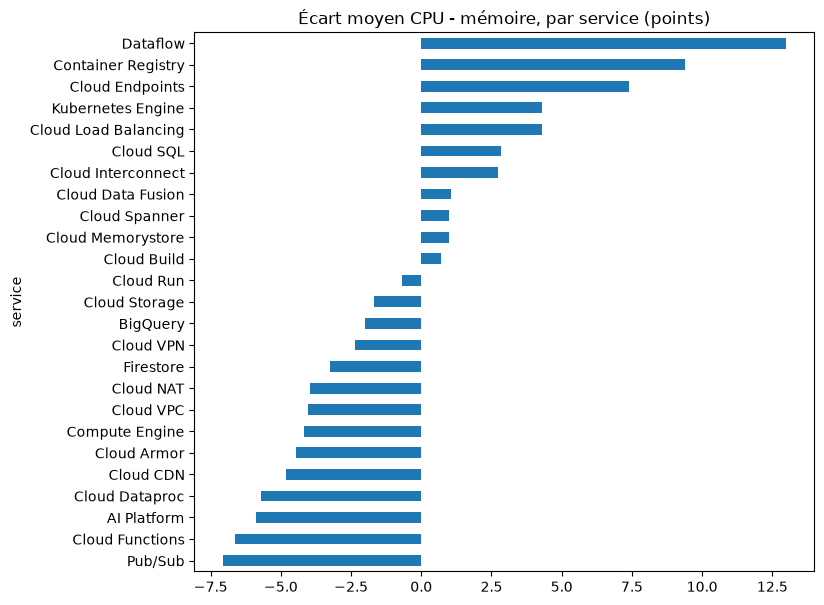

In [9]:
df.groupby("service")["ecart_cpu_mem"].mean().sort_values().plot(
    kind="barh", figsize=(8, 7), title="Écart moyen CPU - mémoire, par service (points)"
)

La moyenne par service va de -7 à +13 points, ce qui est peu quand ils peuvent allés jusqu'à 99. 

Une ressource seule peut pousser à fond sur le CPU ou sur la mémoire, mais une fois qu'on fait la moyenne de tout un service, ces extrêmes se compensent entre eux. 

Aucun service ne penche donc vraiment d'un côté, le déséquilibre se joue ressource par ressource, pas au niveau du service.

## Synthèse

- **CPU vs mémoire** : aucun lien entre les deux (corrélation 0,01). Une ressource
  peut très bien pousser le CPU à fond sans toucher à sa mémoire, et inversement
- **Profils** : à peu près un tiers des ressources penche côté mémoire, un tiers est
  équilibré, un tiers penche côté CPU (entre 314 et 369 ressources par groupe)
- **Profil et coût** : les trois profils coûtent le même prix en moyenne
  (~2 100-2 150 $). Être déséquilibré ne rend pas une ressource plus ou moins chère
- **Cas extrêmes** : certaines ressources montent jusqu'à un écart de 99,5 points
  (quasi 100 % de CPU pour quasi 0 % de mémoire, ou l'inverse). Même ces cas
  extrêmes n'ont pas de coût particulier
- **Par service** : aucun service ne se distingue, la moyenne reste entre -7 et +13
  points partout, ce qui est faible comparé aux écarts individuels (jusqu'à ±99
  points)

Comme pour le trafic réseau (notebook 07) et l'utilisation CPU/mémoire face au coût
(notebook 06) : la façon dont une ressource est utilisée ne dit rien de son prix.
C'est `usage_quantity` × `cost_per_quantity` qui fixe la facture, pas son
dimensionnement.